### Performing Discrete Convolutions

In order to learn how to compute convolutions in one dimension, a naive implementation is shown in the following code block, and the results are compared with the numpy.convolve function. The code is as follows:

In [1]:
import numpy as np
def conv1d(x, w, p=0, s=1):
    w_rot = np.array(w[::-1])
    x_padded = np.array(x)
    if p > 0:
        zero_pad = np.zeros(shape=p)
        x_padded = np.concatenate([
            zero_pad,
            x_padded,
            zero_pad
        ])
    res = []
    for i in range(0, int((len(x_padded) - len(w_rot))) + 1, s):
        res.append(np.sum(x_padded[i:i+w_rot.shape[0]] * w_rot))
    return np.array(res)

## Testing
x = [1, 3, 2, 4, 5, 6, 1, 3]
w = [1, 0, 3, 1, 2]
print('Conv1d Implementation: ',
      conv1d(x, w, p=2, s=1))
print('NumPy Results:',
      np.convolve(x, w, mode='same'))

Conv1d Implementation:  [ 5. 14. 16. 26. 24. 34. 19. 22.]
NumPy Results: [ 5 14 16 26 24 34 19 22]


In the next section, we will cover 2D convolutions in more detail, which are the building blocks of CNNs for image-related tasks.

#### Performing a Discrete Convolution in 2D

Let's also implement the 2D convolution according to the naive algorithm described. The scipy.signal package provides a way to compute 2D convolution via the scipy.signal.convolve2d function:

In [2]:
import numpy as np
import scipy.signal
def conv2d(X, W, p=(0, 0), s=(1, 1)):
    W_rot = np.array(W)[::-1, ::-1]
    X_orig = np.array(X)
    n1 = X_orig.shape[0] + 2*p[0]
    n2 = X_orig.shape[1] + 2*p[1]
    X_padded = np.zeros(shape=(n1, n2))
    X_padded[p[0]:p[0]+X_orig.shape[0], 
             p[1]:p[1]+X_orig.shape[1]] = X_orig
    res = []
    for i in range(0, 
                   int((X_padded.shape[0] - \
                        W_rot.shape[0])/s[0]) + 1, s[0]):
        res.append([])
        for j in range(0,
                       int((X_padded.shape[1] - \
                            W_rot.shape[1])/s[1]) + 1, s[1]):
            X_sub = X_padded[i:i+W_rot.shape[0],
                             j:j+W_rot.shape[1]]
            res[-1].append(np.sum(X_sub * W_rot))
    return np.array(res)

X = [[1, 3, 2, 4], [5, 6, 1, 3], [1, 2, 0, 2], [3, 4, 3, 2]]
W = [[1, 0, 3], [1, 2, 1], [0, 1, 1]]

print('Conv2d Implementation:\n',
      conv2d(X, W, p=(1, 1), s=(1, 1)))

print('SciPy Results:\n',
      scipy.signal.convolve2d(X, W, mode='same'))

Conv2d Implementation:
 [[11. 25. 32. 13.]
 [19. 25. 24. 13.]
 [13. 28. 25. 17.]
 [11. 17. 14.  9.]]
SciPy Results:
 [[11 25 32 13]
 [19 25 24 13]
 [13 28 25 17]
 [11 17 14  9]]


### Putting Everything Together - Implementing a CNN

So far, we have learned about the basic building blocks of CNNs. The concepts illustrated in this chapter are not really more difficult than traditional multilayer NNs. We can say that the most important operation in a traditional NN is matrix multiplication. For instance, we use matrix multiplications to compute the pre-activations (or net inputs), as in $z = Wx + b$. Here, $x$ is a column vector $(\mathbb{R}^{n \times 1} \text{ matrix})$ representing pixels, and $W$ is the weight matrix connecting the pixel inputs to each hidden unit.

In a CNN, this operation is replaced by a convolution operation, as in $Z = W * X + b$ where $X$ is a matrix representing the pixels in a $\text{height} \times \text{width}$ arrangement. In both cases, the pre-activations are passed to an activation function to obtain the activation of a hidden unit, $A = \sigma(Z)$, where $\sigma$ is the activation function. Furthermore, you will recall that subsampling is another building block of a CNN, which may appear in the form of pooling, as was described in the previous section.

#### Working with Multiple Input or Color Channels

When we work with images, we can read images into NumPy arrays using the uint8 (unsigned 8-bit integer) data type to reduce memory usage compared to 16-bit, 32-bit, or 64-bit integer types.

Unsigned 8-bit integers take values in the range [0, 255], which are sufficient to store the pixel information in RGB images, which also take values in the same range.

In Chapter 12, we saw that PyTorch provides a module for loading/storing and manipulating images via torchvision. Let's recap how to read an image:

In [3]:
import torch
from torchvision.io import read_image

img = read_image('example-image.png')
print('Image shape:', img.shape)
print('Number of channels:', img.shape[0])
print('Image data type:', img.dtype)
print(img[:, 100:102, 100:102])

Image shape: torch.Size([3, 252, 221])
Number of channels: 3
Image data type: torch.uint8
tensor([[[179, 182],
         [180, 182]],

        [[134, 136],
         [135, 137]],

        [[110, 112],
         [111, 113]]], dtype=torch.uint8)


Now that you are familiar with the structure of the input data, the next question is, how can we incorporate multiple input channels in the convolution operation that we discussed in the previous sections? The answer is very simple: we perform convolution operation for each channel separately and then add the results together using matrix summation. The convolution associated with each channel $(c)$ has its own kernel matrix as $W[:, :, c]$.

The total pre-activation result is computed in the following formula:

$$
\begin{aligned}
&\text{Given an example } \bm{X}_{n_1\times n_2\times C_{\mathrm{in}}},\\
&\text{a kernel matrix } \bm{W}_{m_1\times m_2\times C_{\mathrm{in}}},\quad \\
&\text{and a bias value } b
\end{aligned}
\quad\Longrightarrow\quad
\left\{\begin{aligned}
&\bm{Z}^{\mathrm{Conv}} = \sum_{c=1}^{C_{\mathrm{in}}}\bm{W}[:,:,c]*\bm{X}[:,:,c]\\
&\text{Pre-activation:}\quad \bm{Z} = \bm{Z}^{\mathrm{Conv}}+b_c\\
&\text{Feature map:}\quad \bm{A} = \sigma(\bm{Z})
\end{aligned}\right.
$$

The final result, $A$, is a feature map. Usually, a convolutional layer of a CNN has more than one feature map. If we use multiple feature maps, the kernel tensor becomes four-dimensional: $width \times height \times C_{in} \times C_{out}$. Here, $width \times height$ is the kernel size, $C_{in}$ is the number of input channels, and $C_{out}$ is the nmber of output feature maps. So, now let's include the number of output feature maps in the preceding formula and update it, as follows:

$$
\begin{aligned}
&\text{Given an example } \bm{X}_{n_1\times n_2\times C_{\mathrm{in}}},\\
&\text{a kernel matrix } \bm{W}_{m_1\times m_2\times C_{\mathrm{in}} \times C_{\mathrm{out}}},\quad \\
&\text{and a bias vector } b_{C_{\mathrm{out}}} 
\end{aligned}
\quad\Longrightarrow\quad
\left\{\begin{aligned}
&\bm{Z}^{\mathrm{Conv}}[:, :, k] = \sum_{c=1}^{C_{\mathrm{in}}}\bm{W}[:,:,c,k]*\bm{X}[:,:,c]\\
&\quad \bm{Z}[:, :, k] = \bm{Z}^{\mathrm{Conv}}[:, :, k]+b[k]\\
&\quad \bm{A}[:, :, k] = \sigma(\bm{Z}[:, :, k])
\end{aligned}\right.
$$


To conclude our discussion of computing convolutions in the context of NNs, let's look at an example which shows a convolutional layer, followed by a pooling layer. In this example, there are three input channels. The kernel tensor is four-dimensional. Each kernel matrix is denoted as $m_1 \times m_2$, and there are three of them, one for each input channel. Furthermore, there are five such kernels, accounting for five output feature maps. Finally, there is a pooling layer for subsampling the feature maps.

Lastly, as was already mentioned, the convolution operations typically are carried out by treating an input image with multiple color channels as a stack of matrices; that is, we perform the convolution on each matrix separately and then add the results. However, convolutions can also be extended to 3D volumes if you are working with 3D datasets.

In the next section, we will talk about how to regularize an NN.

#### Regularizing an NN with L2 Regularization and Dropout

In previous chapters, we covered L1 and L2 regularization. Both techniques can prevent or reduce the effect of overfitting by adding a penalty to the loss that results in shrinking the weight parameters during training. While both L1 and L2 regularization can be used for NNs as well, with L2 being the more common choice of the two, there are other methods for regularizing NNs, such as dropout, which we will discuss in this section. But before we move on to discussing dropout, to use L2 regularization within a convolutional or fully connected network (recall, fully connected layers are implemented via torch.nn.Linear in PyTorch), you can simply add the L2 penalty of a particular layer to the loss function in PyTorch, as follows:

In [4]:
import torch.nn as nn
loss_func = nn.BCELoss()
loss = loss_func(torch.tensor([0.9]), torch.tensor([1.0]))
l2_lambda = 0.001
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=5,
                       kernel_size=5)
l2_penalty = l2_lambda * sum(
    [(p**2).sum() for p in conv_layer.parameters()]
)
loss_with_penalty = loss + l2_penalty
linear_layer = nn.Linear(10, 16)
l2_penalty = l2_lambda * sum(
    [(p**2).sum() for p in linear_layer.parameters()]
)
loss_with_penalty = loss + l2_penalty

#### Loss Functions for Classification

The following code will show you how to use binary cross entropy loss functions with two different formats, where either the logits or class membership probabilities are given as inputs to the loss functions:

In [5]:
### Binary Cross-entropy
logits = torch.tensor([0.8])
probas = torch.sigmoid(logits)
target = torch.tensor([1.0])
bce_loss_fn = nn.BCELoss()
bce_logits_loss_fn = nn.BCEWithLogitsLoss()
print(f'BCE (w Probas): {bce_loss_fn(probas, target):.4f}')
print(f'BCE (w Logits): {bce_logits_loss_fn(logits, target):.4f}')

### Categorical Cross-entropy
logits = torch.tensor([[1.5, 0.8, 2.1]])
probas = torch.softmax(logits, dim=1)
target = torch.tensor([2])
cce_loss_fn = nn.NLLLoss()
cce_logits_loss_fn = nn.CrossEntropyLoss()
print(f'CCE (w Probas): {cce_loss_fn(torch.log(probas), target):.4f}')
print(f'CCE (w Logits): {cce_logits_loss_fn(logits, target):.4f}')

BCE (w Probas): 0.3711
BCE (w Logits): 0.3711
CCE (w Probas): 0.5996
CCE (w Logits): 0.5996


### Implementing a Deep CNN using PyTorch

Let's implement a CNN and see whether it can achieve a better predictive performance compared to the previous model for classifying handwritten digits. Note that the fully connected layers that we saw in a previous chapter were able to perform well on this problem. However, in some applications, such as reading bank account numbers from handwritten digits, even tiny mistakes can be very costly. Therefore, it is crucial to reduce this error as much as possible.

#### The Multilayer CNN architecture

The architecture of the network that we are going to implement has inputs that are $28 \times 28$ grayscale images. Considering the number of channels (which is 1 for grayscale images) and a batch of input images, the input tensor's dimensions will be $batchsize \times 28 \times 28 \times 1$.

The input data goes through two convolutional layers that have a kernel size of $5 \times 5$. The first convolution has 32 output feature maps, and the second one has 64 output feature maps. Each convolution layer is followed by a subsampling layer in the form of a max-pooling operation $P_{2 \times 2}$. Then a fully connected layer passes the output to a second fully connected layer, which acts as the final softmax output layer.

The dimensions of the tensors in each layer are as follows:

- Input: $[batchsize \times 28 \times 28 \times 1]$
- Conv_1: $[batchsize \times 28 \times 28 \times 32]$
- Pooling_1: $[batchsize \times 14 \times 14 \times 64]$
- Conv_2: $[batchsize \times 14 \times 14 \times 64]$
- Pooling_2: $[batchsize \times 7 \times 7 \times 64]$
- FC_1: $[batchsize \times 1024]$
- FC_2 and softmax layer: $[batchsize \times 10]$

For the convolutional kernels, we are using stride=1 such that the input dimensions are preserved in the resulting feature maps. For the pooling layers, we are using kernel_size = 2 to subsample the image and shrink the size of the output feature maps. We will implement this netowrk using the PyTorch NN module.

#### Loading and Preprocessing the Data

First, we will load the MNIST dataset using the torchvision module and construct the training and test sets:

In [6]:
import torchvision
from torchvision import transforms

image_path = './'
transform = transforms.Compose([
    transforms.ToTensor()
])

mnist_dataset = torchvision.datasets.MNIST(
    root=image_path,
    train=True,
    transform=transform,
    download=True
)

from torch.utils.data import Subset

mnist_valid_dataset = Subset(mnist_dataset,
                             torch.arange(10000))
mnist_train_dataset = Subset(mnist_dataset,
                             torch.arange(10000, len(mnist_dataset)))

mnist_test_dataset = torchvision.datasets.MNIST(
    root=image_path, train=False,
    transform=transform,
    download=False
)

The MNIST dataset comes with a pre-specified training and test dataset partitioning scheme, but we also want to create a validation split from the train partition. Hence, we used the first 10,000 training examples for validation. Note that the images are not sorted by class label, so we do not have to worry about whether those validation set images are from the same classes.

Next, we will construct the data loader with batches of 64 images for the training set and validation set, respectively:

In [7]:
from torch.utils.data import DataLoader
batch_size = 64
torch.manual_seed(1)
train_dl = DataLoader(mnist_train_dataset,
                      batch_size,
                      shuffle=True)
valid_dl = DataLoader(mnist_valid_dataset,
                      batch_size,
                      shuffle=False)

The features we read are of values in range [0, 1]. Also, we already converted the images to tensors. The labels are integers from 0 to 9, representing ten digits. Hence, we don't need to do any scaling or further conversion.

Now, after preparing the dataset, we are ready to implement the CNN we just described.

### Implementing a CNN Using the torch.nn Module

For implementing a CNN in PyTorch, we use the torch.nn.Sequential class to stack different layers, such as convolution, pooling, and dropout, as well as the fully connected layers. The torch.nn module provides classes for each one: nn.Conv2d for a two-dimensional convolution layer; nn.MaxPool2d and nn.AvgPool2d for subsampling (max-pooling and average pooling); and nn.Dropout for regularization using dropout. We will go over each of these classes in more detail.

#### Configuring CNN Layers in PyTorch

Constructing a layer with the Conv2d class requires us to specify the number of output channels (which is equivalent to the number of output feature maps, or the number of output filters) and kernel sizes.

In addition, there are optional parameters that we can use to configure a convolutional layer. The most commonly used ones are the strides (with a default value of 1 in both $x,y$ dimensions) and padding, which controls the amount of implicit padding on both dimensions. 

It is worth mentioning that usually, when we read an image, the default dimension for the channels is the first dimension of the tensor array (or the second dimension considering the batch dimension). This is called the NCHW format, where N stands for the number of images within the batch, C stands for channels, and H and W stand for height and width, respectively.

Note that the Conv2D class assumes that inputs are in NCHW format by default. (Other tools, such as TensorFlow, use NHWC format.) However, if you come across some data whose channels are placed at the last dimension, you would need to swap the axes in your data to move the channels to the first dimension (or the second dimension considering the batch dimension). After the layer is constructed, it can be called by providing a four-dimensional tensor, with the first dimension reserved for a batch of examples; the second dimension corresponds to the channel; and the other two dimensions are the spatial dimensions.

As shown in the architecture of the CNN model that we want to build, each convolution layer is followed by a pooling layer for subsampling (reducing the size of the feature maps). The MaxPool2s and AvgPool2d classes construct the max-pooling and average-pooling layers, respectively. The kernel_size argument determines the size of the window (or neighborhood) that will be used to compute the max or mean operations. Furthermore, the stride parameter can be used to configure the pooling layer, as we discussed earlier.

Finally, the Dropout class will construct the dropout layer for regularization, with the argument $p$ that denotes the drop probability $p_{drop}$, which is used to determine the probability of dropping the input units during training, as we discussed earlier. When calling this layer, its behavior can be controlled via model.train() and model.eval(), to specify whether this call will be made during training or during the inference. When using dropout, alternating between these two modes is crucial to ensure that it behaves correctly; for instance, nodes are only randomly dropped during training, not evaluation or inference.

#### Constructing a CNN in PyTorch

Now that we have learned about these classes, we can construct the CNN model that was shown in the previous section. In the following code, we will use the Sequential class and add the convolution and pooling layers:

In [8]:
model = nn.Sequential()
model.add_module(
    'conv1',
    nn.Conv2d(
        in_channels=1,
        out_channels=32,
        kernel_size=5,
        padding=2
    )
)
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(kernel_size=2))
model.add_module(
    'conv2',
    nn.Conv2d(
        in_channels=32,
        out_channels=64,
        kernel_size=5,
        padding=2
    )
)
model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(kernel_size=2))

So far, we have added two convolution layers to the model. For each convolutional layer, we used a kernel of size $5 \times 5$ and padding=2. As discussed earlier, using same padding mode preserves the spatial dimensions (vertical and horizontal dimensions) of the feature maps such that the inputs and outputs have the same height and width (and the number of channels may only differ in terms of the number of filters used). As mentioned before, the spatial dimension of the output feature map is calculated by eq 4 where $n$ is the spatial dimension of the input feature map, and $p, m$ and $s$ denote the padding, kernel size, and stride, respectively. We obtain $p=2$ in order to achieve $o=i$.

The max-pooling layers with pooling size $2 \times 2$ and stride of 2 will reduce the spatial dimensions by half. (Note that if the stride parameter is not specified in MaxPool2D, by default, it is set equal to the pooling kernel size.)

While we can calculate the size of the feature maps at this stage manually, PyTorch provides a convenient method to compute this for us:

In [9]:
x = torch.ones((4, 1, 28, 28))
model(x).shape

torch.Size([4, 64, 7, 7])

By providing the input shape as a tuple (4, 1, 28, 28) (4 images within the batch, 1 channel, and image size $28 \times 28$), specified in this example, we calculated the output to have a shape (4, 64, 7, 7), indicating feature maps with 64 channels and a spatial size of $7 \times 7$. The first dimension corresponds to the batch dimension, for which we used 4 arbitrarily.

The next layer that we want to add is a fully connected layer for implementing a classifier on top of our convolutional and pooling layers. The input to this layer must have rank 2, that is, shape $[batchsize \times input_units]$. Thus, we need to flatten the output of the previous layers to meet this requirement for the fully connected layer:

In [10]:
model.add_module('flatten', nn.Flatten())
x = torch.ones((4, 1, 28, 28))
model(x).shape

torch.Size([4, 3136])

As the output shape indicates, the input dimensions for the fully connected layers are correctly set up. Next, we will add two fully connected layers with a dropout layer in between:

In [11]:
model.add_module('fc1', nn.Linear(3136, 1024))
model.add_module('relu3', nn.ReLU())
model.add_module('dropout', nn.Dropout(p=0.5))
model.add_module('fc2', nn.Linear(1024, 10))

The last fully connected layer, named 'fc2', has 10 output units for the 10 class labels in the MNIST dataset. In practice, we usually use the softmax activation to obtain the class-membership probabilities of each input example, assuming that the classes are mutually exclusive, so the probabilities for each example sum to 1. However, the softmax function is already used internally inside PyTorch's CrossEntropyLoss implementation, which is why we don't have to explicitly add it as a layer after the output layer above. The following code will create the loss function and optimizer for the model:

In [12]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Note that in this implementation, we uesd the torch.optim.Adam class for training the CNN model. The Adam optimizer is a robust, gradient-based optimization method suited to nonconvex optimization and machine learning problems. Two popular optimization methods inspired Adam: RMSProp and AdaGrad.

The key advantage of Adam is in the choice of the update step size derived from the running average of the gradient moments.

Now we can train the model by defining the following function:

In [13]:
def train(model, num_epochs, train_dl, valid_dl):
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs
    for epoch in range(num_epochs):
        model.train()
        for x_batch, y_batch in train_dl:
            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_hist_train[epoch] += loss.item() * y_batch.size(0)
            is_correct = (
                torch.argmax(pred, dim=1) == y_batch
            ).float()
            accuracy_hist_train[epoch] += is_correct.sum()
        loss_hist_train[epoch] /= len(train_dl.dataset)
        accuracy_hist_train[epoch] /= len(train_dl.dataset)

        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in valid_dl:
                pred = model(x_batch)
                loss = loss_fn(pred, y_batch)
                loss_hist_valid[epoch] += \
                    loss.item() * y_batch.size(0)
                is_correct = (
                    torch.argmax(pred, dim=1) == y_batch
                ).float()
                accuracy_hist_valid[epoch] += is_correct.sum()
            loss_hist_valid[epoch] /= len(valid_dl.dataset)
            accuracy_hist_valid[epoch] /= len(valid_dl.dataset)

            print(f'Epoch {epoch+1} accuracy: '
                  f'{accuracy_hist_train[epoch]:.4f} val_accuracy: '
                  f'{accuracy_hist_valid[epoch]:.4f}')

    return loss_hist_train, loss_hist_valid, \
           accuracy_hist_train, accuracy_hist_valid
    

Note that using the designated settings for training model.train() and evaluation model.eval() will automatically set the mode for the dropout layer and rescale the hidden units appropriately so that we do not have to worry about that at all. Next, we will trian this CNN model and use the validation dataset that we created for monitoring the learning progress:

In [14]:
torch.manual_seed(1)
num_epochs = 20
hist = train(model, num_epochs, train_dl, valid_dl)


Epoch 1 accuracy: 0.9483 val_accuracy: 0.9806
Epoch 2 accuracy: 0.9840 val_accuracy: 0.9843
Epoch 3 accuracy: 0.9888 val_accuracy: 0.9887
Epoch 4 accuracy: 0.9916 val_accuracy: 0.9891
Epoch 5 accuracy: 0.9937 val_accuracy: 0.9883
Epoch 6 accuracy: 0.9942 val_accuracy: 0.9884
Epoch 7 accuracy: 0.9950 val_accuracy: 0.9902
Epoch 8 accuracy: 0.9960 val_accuracy: 0.9900
Epoch 9 accuracy: 0.9968 val_accuracy: 0.9893
Epoch 10 accuracy: 0.9972 val_accuracy: 0.9878
Epoch 11 accuracy: 0.9969 val_accuracy: 0.9893
Epoch 12 accuracy: 0.9969 val_accuracy: 0.9908
Epoch 13 accuracy: 0.9980 val_accuracy: 0.9911
Epoch 14 accuracy: 0.9975 val_accuracy: 0.9907
Epoch 15 accuracy: 0.9973 val_accuracy: 0.9899
Epoch 16 accuracy: 0.9981 val_accuracy: 0.9911
Epoch 17 accuracy: 0.9975 val_accuracy: 0.9895
Epoch 18 accuracy: 0.9984 val_accuracy: 0.9907
Epoch 19 accuracy: 0.9985 val_accuracy: 0.9909
Epoch 20 accuracy: 0.9985 val_accuracy: 0.9908


Once the 20 epochs of training are finished, we can visualize the learning curves:

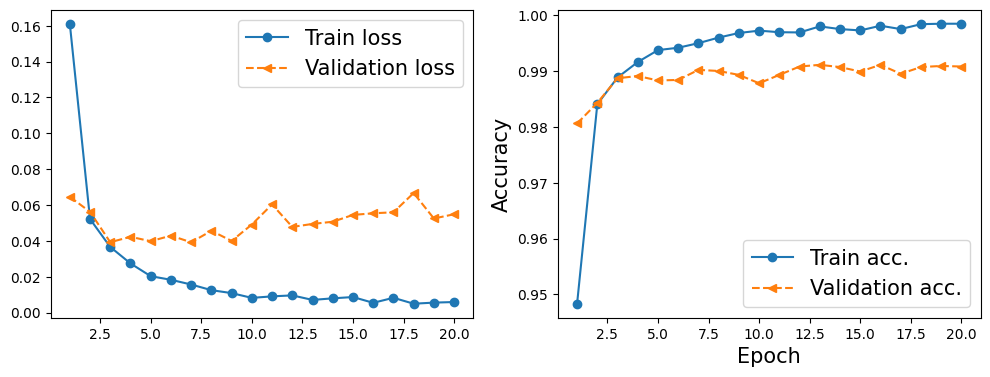

In [15]:
import matplotlib.pyplot as plt
x_arr = np.arange(len(hist[0])) + 1
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist[0], '-o', label='Train loss')
ax.plot(x_arr, hist[1], '--<', label='Validation loss')
ax.legend(fontsize=15)
ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist[2], '-o', label='Train acc.')
ax.plot(x_arr, hist[3], '--<', label='Validation acc.')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Accuracy', size=15)
plt.show()

Now, we evaluate the trained model on the test dataset:

In [16]:
test_dl = DataLoader(mnist_test_dataset, batch_size=256, shuffle=False)
model.eval()
correct = 0
with torch.inference_mode():
    for x_batch, y_batch in test_dl:
        correct += (model(x_batch).argmax(1) == y_batch).sum().item()
print(f"Test accuracy: {correct / len(mnist_test_dataset):.4f}")


Test accuracy: 0.9919


The CNN model achieves an accuracy of 99.19 percent. Remember that in the previous chapter, we got approximately 95 percent accuracy using only fully connected (instead of convolutional) layers.

Finally, we can get the prediction results in the form of class-membership probabilities and convert them to predicted labels by using the torch.argmax function to find the element with the maximum probability. We will do this for a batch of 12 examples and visualize the input and predicted labels:

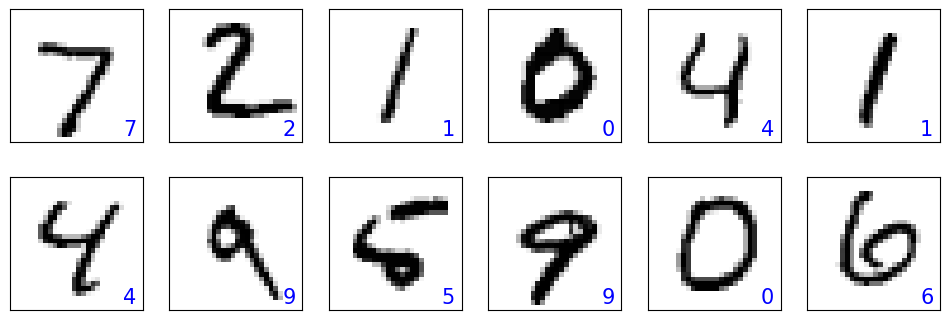

In [17]:
fig = plt.figure(figsize=(12, 4))
for i in range(12):
    ax = fig.add_subplot(2, 6, i + 1)
    ax.set_xticks([])
    ax.set_yticks([])
    img = mnist_test_dataset[i][0][0, :, :]
    with torch.inference_mode():
        y_pred = model(img[None, None]).argmax()
    ax.imshow(img, cmap='gray_r')
    ax.text(0.9, 0.1, y_pred.item(),
            size=15, color='blue',
            horizontalalignment='center',
            verticalalignment='center',
            transform=ax.transAxes)
plt.show()

In this set of plotted examples, all the predicted labels are correct.

### Smile Classification from Face Images Using a CNN

In this section, we are going to implement a CNN for smile classification from face images using the CelebA dataset. CelebA dataset contains 202,599 images of celebrities' faces. In addition, 40 binary facial attributes are available for each image, including whether a celebrity is smiling (or not) and their age (young or old).

Based on what we have learned so far, the goal of this section is to build and train a CNN model for predicting the smile attribute from these face images. Here, for simplicity, we will only be using a small portion of the training data (16,000 training examples) to speed up the training process. However, to improve the generalization performance and reduce overfitting on such a small dataset, we will use a technique called **data augmentation**.

#### Loading the CelebA dataset

First, let's load the data similarly to how we did in the previous section for the MNIST dataset. CelebA data comes in three partitions: a training dataset, a validation dataset, and a test dataset. Next, we will count the number of exmaples in each partition:

In [18]:
image_path = './'
celeba_train_dataset = torchvision.datasets.CelebA(
    image_path, split='train',
    target_type='attr', download=False
)

celeba_valid_dataset = torchvision.datasets.CelebA(
    image_path, split='valid',
    target_type='attr', download=False
)

celeba_test_dataset = torchvision.datasets.CelebA(
    image_path, split='test',
    target_type='attr', download=False
)

#### Image Transformation and Data Augmentation

In the following code block, we will first get five examples from the celeba_train_dataset and apply five different types of transformation:
- cropping an image to a bounding box
- flipping an image horizontally
- adjusting the contrast
- adjusting the brightness
- center-cropping an image and resizing the resulting image back to its original size (218, 178)

In the following code, we will visualize the results of these transformations, showing each one in a separate column for comparison:

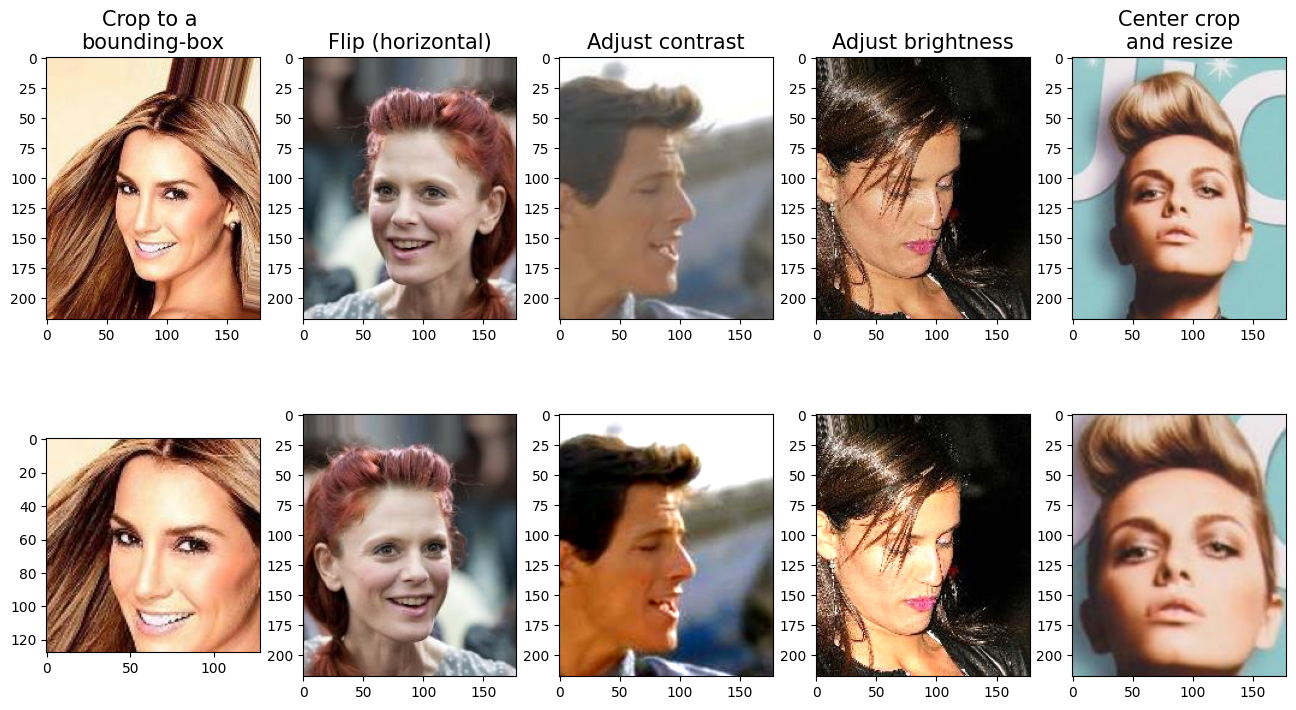

In [19]:
fig = plt.figure(figsize=(16, 8.5))
## Column 1: cropping to a bounding-box
ax = fig.add_subplot(2, 5, 1)
img, attr = celeba_train_dataset[0]
ax.set_title('Crop to a \nbounding-box', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 6)
img_cropped = transforms.functional.crop(img, 50, 20, 128, 128)
ax.imshow(img_cropped)

## Column 2: flipping (horizontally)
ax = fig.add_subplot(2, 5, 2)
img, attr = celeba_train_dataset[1]
ax.set_title('Flip (horizontal)', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 7)
img_flipped = transforms.functional.hflip(img)
ax.imshow(img_flipped)

## Column 3: adjust contrast
ax = fig.add_subplot(2, 5, 3)
img, attr = celeba_train_dataset[2]
ax.set_title('Adjust contrast', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 8)
img_adj_contrast = transforms.functional.adjust_contrast(img, contrast_factor=2)
ax.imshow(img_adj_contrast)

## Column 4: adjust brightness
ax = fig.add_subplot(2, 5, 4)
img, attr = celeba_train_dataset[3]
ax.set_title('Adjust brightness', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 9)
img_adj_brightness = transforms.functional.adjust_brightness(
    img, brightness_factor=1.3
)
ax.imshow(img_adj_brightness)

## Column 5: cropping from image center
ax = fig.add_subplot(2, 5, 5)
img, attr = celeba_train_dataset[4]
ax.set_title('Center crop\nand resize', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 10)
img_center_crop = transforms.functional.center_crop(
    img, [0.7*218, 0.7*178]
)
img_resized = transforms.functional.resize(
    img_center_crop, size=(218, 178)
)
ax.imshow(img_resized)
plt.show()


The original images are shown in the first row and their transformed versions in the second row. Note that for the first transformation (leftmost column), the bounding box is specified by four numbers: the coordinate of the upper-left corner of the bounding box (here $x=20$, $y=50$) and the width and the height of the box (width=128, height=128).Also note that the origin (the coordinates at the location denoted as (0, 0)) for images loaded by PyTorch (as well as other packages such as imageio) is the upper-left corner of the image.

The transformations in the previous code block are deterministic. However, all such transformations can also be randomized, which is recommended for data augmentation during model training. For example, a random bounding box (where the coordinates of the upper-left corner are selected randomly) can be cropped from an image, an image can be randomly flipped along either the horizontal or vertical axes with a probability of 0.5, or the contrast of an image can be changed randomly, where the contrast_factor is selected at random, but with uniform distribution, from a range of values. In addition, we can create a pipeline of these transformations.

For example, we can first randomly crop an image, then flip it randomly, and finally, resize it to the desired size. The code is as follows (since we have random elements, we set the random seed for reproducibility):

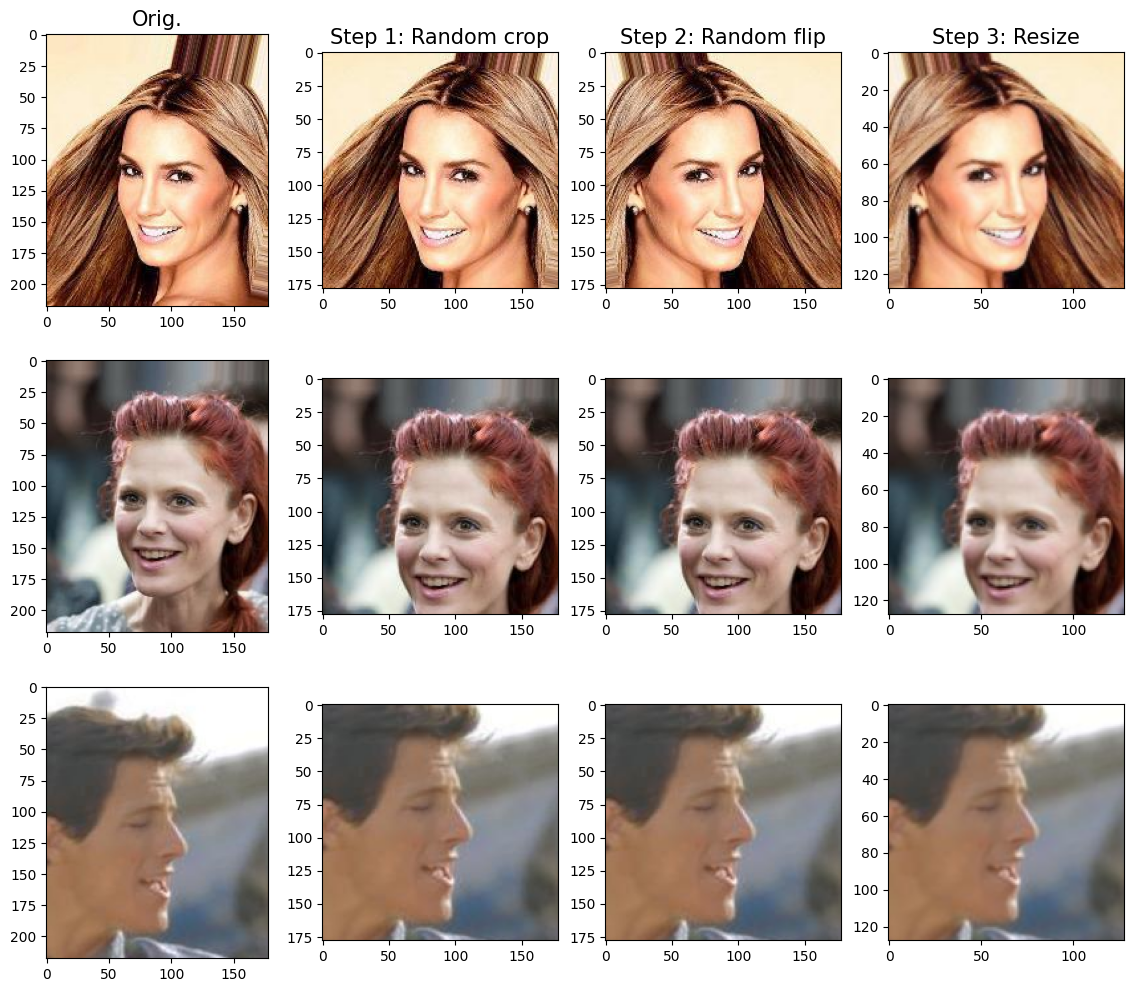

In [20]:
torch.manual_seed(1)
fig = plt.figure(figsize=(14, 12))
for i, (img, attr) in enumerate(celeba_train_dataset):
    ax = fig.add_subplot(3, 4, i*4 + 1)
    ax.imshow(img)
    if i == 0:
        ax.set_title('Orig.', size=15)

    ax = fig.add_subplot(3, 4, i*4 + 2)
    img_transform = transforms.Compose([
        transforms.RandomCrop([178, 178])
    ])
    img_cropped = img_transform(img)
    ax.imshow(img_cropped)
    if i == 0:
        ax.set_title('Step 1: Random crop', size=15)

    ax = fig.add_subplot(3, 4, i*4+3)
    img_transform = transforms.Compose([
        transforms.RandomHorizontalFlip()
    ])
    img_flip = img_transform(img_cropped)
    ax.imshow(img_flip)
    if i == 0:
        ax.set_title('Step 2: Random flip', size=15)

    ax = fig.add_subplot(3, 4, i*4+4)
    img_resized = transforms.functional.resize(
        img_flip, size=(128, 128)
    )
    ax.imshow(img_resized)
    if i == 0:
        ax.set_title('Step 3: Resize', size=15)
    if i == 2:
        break

plt.show()

Note that each time we iterate through these three examples, we get slightly different images due to random transformations.

For convenience, we can define transform functions to use this pipeline for data augmentation during dataset loading. In the following code, we will define the function get_smile, which will extract the smile label from the 'attributes' list:

In [21]:
get_smile = lambda attr: attr[31]

We will define the transform_train function that will produce the transformed image (where we will first randomly crop the image, then flip it randomly, and finally, resize it to the desired size $64 \times 64$):

In [22]:
transform_train = transforms.Compose([
    transforms.RandomCrop([178, 178]),
    transforms.RandomHorizontalFlip(),
    transforms.Resize([64, 64]),
    transforms.ToTensor(),
])

We will only apply data augmentation to the training examples, however, and not to the validation or test images. The code for valiation or test set is as follows (where we will first simply crop the image and then resize it to the desired size $64 \times 64$):

In [23]:
transform = transforms.Compose([
    transforms.CenterCrop([178, 178]),
    transforms.Resize([64, 64]),
    transforms.ToTensor(),
])

Now, to see data augmentation in action, let's apply the transform_train function to our training dataset and iterate over the dataset five times:

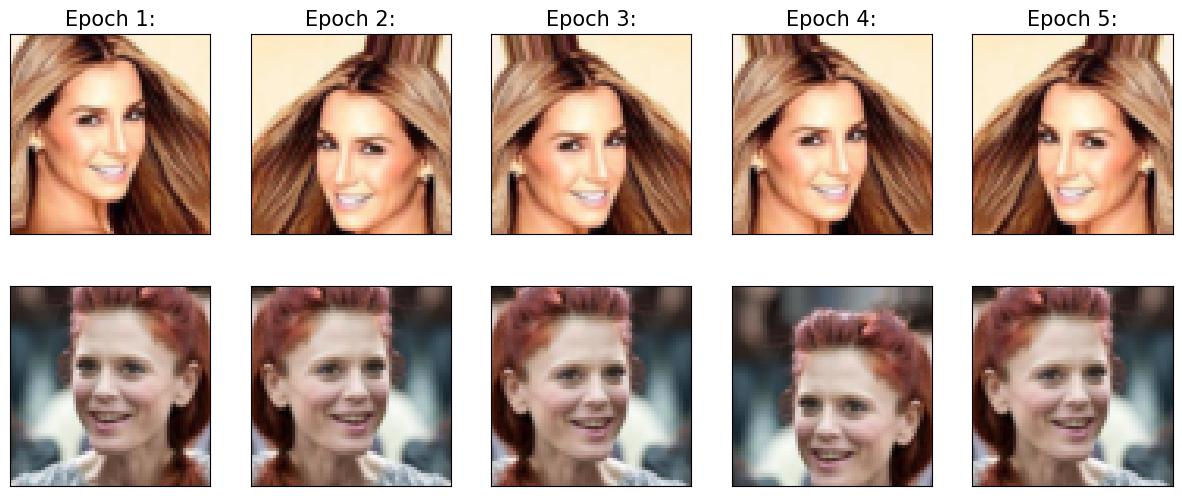

In [24]:
from torch.utils.data import DataLoader
celeba_train_dataset = torchvision.datasets.CelebA(
    image_path, split='train',
    target_type='attr', download=False,
    transform=transform_train, target_transform=get_smile
)
torch.manual_seed(1)
data_loader = DataLoader(celeba_train_dataset, batch_size=2)
fig = plt.figure(figsize=(15, 6))
num_epochs = 5
for j in range(num_epochs):
    img_batch, label_batch = next(iter(data_loader))
    img = img_batch[0]
    ax = fig.add_subplot(2, 5, j+1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'Epoch {j+1}:', size=15)
    ax.imshow(img.permute(1,2,0))

    img = img_batch[1]
    ax = fig.add_subplot(2, 5, j+6)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(img.permute(1,2,0))

plt.show()

Next, we will apply the transform function to our validation and test datasets:

In [25]:
celeba_valid_dataset = torchvision.datasets.CelebA(
    image_path, split='valid',
    target_type='attr', download=False,
    transform=transform, target_transform=get_smile
)

celeba_test_dataset = torchvision.datasets.CelebA(
    image_path, split='test',
    target_type='attr', download=False,
    transform=transform, target_transform=get_smile
)

Furthermore, instead of using all the available training and validation data, we will take a subset of 16,000 training examples and 1,000 examples for validation, as our goal here is to intentionally train our model with a small dataset:

In [26]:
from torch.utils.data import Subset
celeba_train_dataset = Subset(celeba_train_dataset,
                              torch.arange(16000))
celeba_valid_dataset = Subset(celeba_valid_dataset,
                              torch.arange(1000))
print('Train set:', len(celeba_train_dataset))
print('Validation set:', len(celeba_valid_dataset))

Train set: 16000
Validation set: 1000


In [27]:
batch_size = 32
torch.manual_seed(1)
train_dl = DataLoader(celeba_train_dataset,
                      batch_size, shuffle=True)
valid_dl = DataLoader(celeba_valid_dataset,
                      batch_size, shuffle=False)
test_dl = DataLoader(celeba_test_dataset,
                     batch_size, shuffle=False)

Now that the data loaders are ready, we will develop a CNN model, and train and evaluate it in the next section.

### Training a CNN Smile Classifier

By now, building a model with torch.nn module and training it should be straightforward. The design of our CNN is as follows: the CNN model receives input images of size $3 \times 64 \times 64$ (the images have three color channels).

The input data goes through four convolutional layers to make 32, 64, 128, and 256 feature maps using filters with a kernel size of $3 \times 3$ and padding of 1 for same padding. The first three convolution layesr are followed by max-pooling, $P_{2 \times 2}$. Two dropout layers are also included for regularization:

In [28]:
model = nn.Sequential()
model.add_module(
    'conv1',
    nn.Conv2d(
        in_channels=3, out_channels=32,
        kernel_size=3, padding=1
    )
)
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(kernel_size=2))
model.add_module('dropout1', nn.Dropout(p=0.5))

model.add_module(
    'conv2',
    nn.Conv2d(
        in_channels=32, out_channels=64,
        kernel_size=3, padding=1
    )
)
model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(kernel_size=2))
model.add_module('dropout2', nn.Dropout(p=0.5))

model.add_module(
    'conv3',
    nn.Conv2d(
        in_channels=64, out_channels=128,
        kernel_size=3, padding=1
    )
)
model.add_module('relu3', nn.ReLU())
model.add_module('pool3', nn.MaxPool2d(kernel_size=2))

model.add_module(
    'conv4',
    nn.Conv2d(
        in_channels=128, out_channels=256,
        kernel_size=3, padding=1
    )
)
model.add_module('relu4', nn.ReLU())

Let's see the shape of the output feature maps after applying these layers using a toy batch input:

In [29]:
x = torch.ones((4, 3, 64, 64))
model(x).shape

torch.Size([4, 256, 8, 8])

There are 256 feature maps (or channels) of size $8 \times 8$. Now, we can add a fully connected layer to get to the output layer with a single unit. If we reshape (flatten) the feature maps, the number of input units to this fully connected layer will be $8 \times 8 \times 256 = 16,384$. Alternatively, let's consider a new layer, called global average-pooling, which computes the average of each feature map separately, thereby reducing the hidden units to 256. We can then add a fully connected layer. Although we have not discussed global average-pooling explicitly, it is conceptually very similar to other pooling layers. Global average-pooling can be viewed, in fact, as a special case of average-poolng when the pooling size is equal to the size of the input feature maps.

Given that, in our case, the shape of the feature maps prior to this layer is $[batchsize \times 256 \times 8 \times 8]$, we expect to get 256 units as output, that is, the shape of the output will be $[batchsize \times 256]$. Let's add this layer and recompute the output shape to verify that this is true:

In [30]:
model.add_module('pool4', nn.AvgPool2d(kernel_size=8))
model.add_module('flatten', nn.Flatten())
x = torch.ones((4, 3, 64, 64))
model(x).shape

torch.Size([4, 256])

Finally, we can add a fully connected layer to get a single output unit. In this case, we can specify the activation function to be 'sigmoid':

In [31]:
model.add_module('fc', nn.Linear(256, 1))
model.add_module('sigmoid', nn.Sigmoid())
x = torch.ones((4, 3, 64, 64))
print(model(x).shape)
model

torch.Size([4, 1])


Sequential(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.5, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu4): ReLU()
  (pool4): AvgPool2d(kernel_size=8, stride=8, padding=0)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

The next step is to create a loss function and optimizer (Adam optimizer again). For a binary classificaiton with a single output unit, we can use the binary cross-entropy loss for the loss function:

In [32]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Now, we can train the model by defining the following function:

In [33]:
def train(model, num_epochs, train_dl, valid_dl):
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs

    for epoch in range(num_epochs):
        model.train()
        for x_batch, y_batch in train_dl:
            pred = model(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch.float())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_hist_train[epoch] += loss.item() * y_batch.size(0)
            is_correct = ((pred>=0.5).float() == y_batch).float()
            accuracy_hist_train[epoch] += is_correct.sum()
        loss_hist_train[epoch] /= len(train_dl.dataset)
        accuracy_hist_train[epoch] /= len(train_dl.dataset)

        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in valid_dl:
                pred = model(x_batch)[:, 0]
                loss = loss_fn(pred, y_batch.float())
                loss_hist_valid[epoch] += loss.item() * y_batch.size(0)
                is_correct = ((pred>=0.5).float() == y_batch).float()
                accuracy_hist_valid[epoch] += is_correct.sum()
            loss_hist_valid[epoch] /= len(valid_dl.dataset)
            accuracy_hist_valid[epoch] /= len(valid_dl.dataset)

        print(f'Epoch {epoch+1} accuracy: '
              f' {accuracy_hist_train[epoch]:.4f}, '
              f'val_accuracy: {accuracy_hist_valid[epoch]:.4f}')

    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid

Next, we will train this CNN model for 30 epochs and use the validation dataset that we created for monitoring the learning progress:

In [34]:
torch.manual_seed(1)
num_epochs = 30
hist = train(model, num_epochs, train_dl, valid_dl)

Epoch 1 accuracy:  0.5089, val_accuracy: 0.5140
Epoch 2 accuracy:  0.5251, val_accuracy: 0.5570
Epoch 3 accuracy:  0.5434, val_accuracy: 0.5750
Epoch 4 accuracy:  0.5891, val_accuracy: 0.5960
Epoch 5 accuracy:  0.6184, val_accuracy: 0.6380
Epoch 6 accuracy:  0.6444, val_accuracy: 0.6550
Epoch 7 accuracy:  0.6628, val_accuracy: 0.6730
Epoch 8 accuracy:  0.6762, val_accuracy: 0.6840
Epoch 9 accuracy:  0.6929, val_accuracy: 0.6990
Epoch 10 accuracy:  0.7041, val_accuracy: 0.7190
Epoch 11 accuracy:  0.7277, val_accuracy: 0.7350
Epoch 12 accuracy:  0.7487, val_accuracy: 0.7980
Epoch 13 accuracy:  0.7621, val_accuracy: 0.8250
Epoch 14 accuracy:  0.7859, val_accuracy: 0.8080
Epoch 15 accuracy:  0.8016, val_accuracy: 0.8400
Epoch 16 accuracy:  0.8167, val_accuracy: 0.8560
Epoch 17 accuracy:  0.8256, val_accuracy: 0.8550
Epoch 18 accuracy:  0.8294, val_accuracy: 0.8640
Epoch 19 accuracy:  0.8413, val_accuracy: 0.8710
Epoch 20 accuracy:  0.8415, val_accuracy: 0.8890
Epoch 21 accuracy:  0.8484, v

Let's now visualize the learning curve and compare the training and validation loss and accuracies after each epoch:

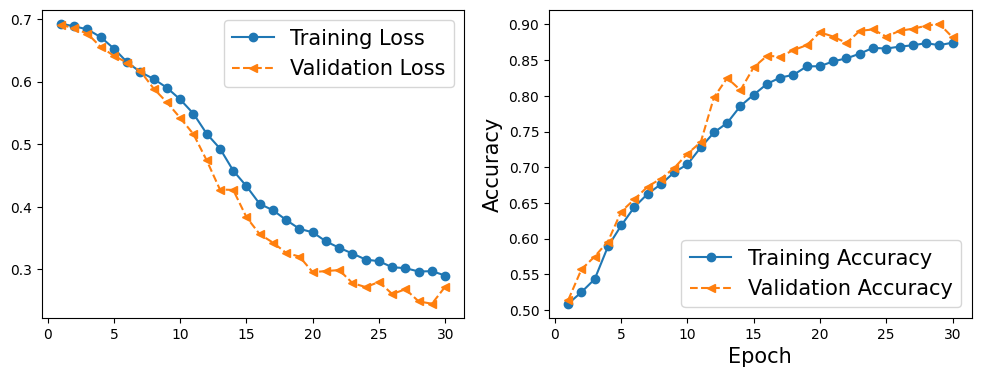

In [35]:
x_arr = np.arange(len(hist[0])) + 1
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist[0], '-o', label='Training Loss')
ax.plot(x_arr, hist[1], '--<', label='Validation Loss')
ax.legend(fontsize=15)
ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist[2], '-o', label='Training Accuracy')
ax.plot(x_arr, hist[3], '--<', label='Validation Accuracy')
ax.legend(fontsize=15)

ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Accuracy', size=15)
plt.show()

Once we are happy with the learning curves, we can evaluate the model on the hold-out test dataset:

In [36]:
accuracy_test = 0
model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_dl:
        pred = model(x_batch)[:, 0]
        is_correct = ((pred >=0.5).float() == y_batch).float()
        accuracy_test += is_correct.sum()
accuracy_test /= len(test_dl.dataset)
print(f'Test accuracy: {accuracy_test:.4f}')

Test accuracy: 0.8936


Finally, we already know how to get the prediction results on some test examples. In the following code, we will take a small subset of 10 examples from the last batch of our pre-processed test dataset (test_dl). Then, we will compute the probabilities of each example being from class 1 (which corresponds to smile based on the labels provided in CelebA) and visualize the examples along with their ground truth label and predicted probabilities:

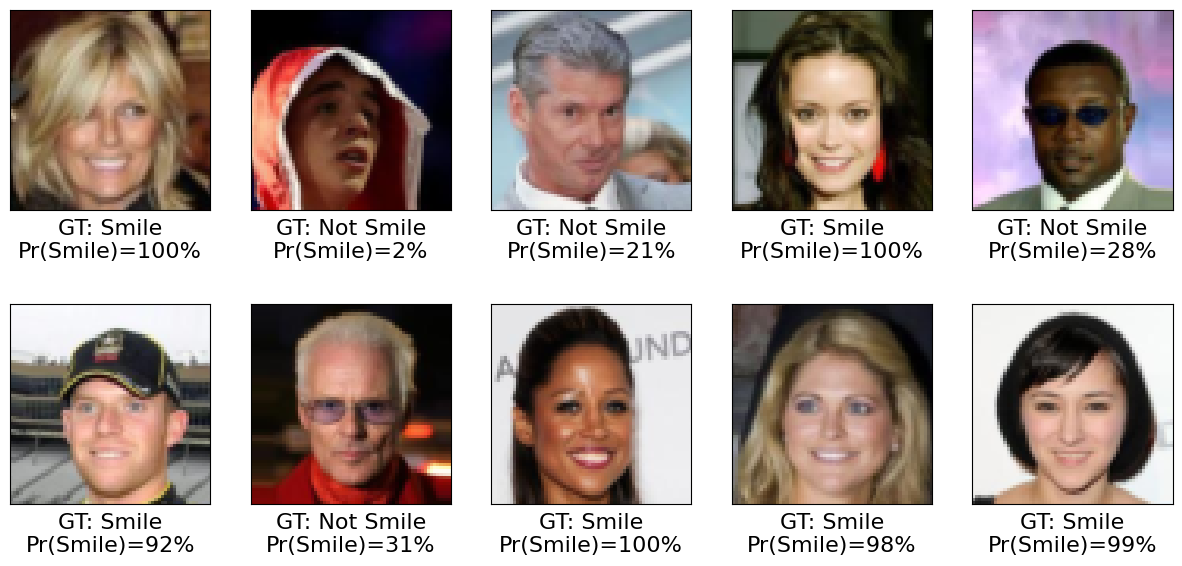

In [37]:
pred = model(x_batch)[:, 0] * 100
fig = plt.figure(figsize=(15, 7))
for j in range(10, 20):
    ax = fig.add_subplot(2, 5, j-10+1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(x_batch[j].permute(1, 2, 0))
    if y_batch[j] == 1:
        label='Smile'
    else:
        label='Not Smile'
    ax.text(
        0.5, -0.15,
        f'GT: {label:s}\nPr(Smile)={pred[j]:.0f}%',
        size=16,
        horizontalalignment='center',
        verticalalignment='center',
        transform=ax.transAxes
    )
plt.show()

The probabilities of class 1 (that is, smile according to CelebA) are provided below each image. As you can see, our trained model is completely accurate on this set of 10 test examples.